In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import csv

====== 各分區資料摘要統計表格 (Non-IID 檢核) ======


,時間分區,總樣本數,糖尿病 (1),非糖尿病 (0),LBXGH 平均值,LBXGH 標準差,LBXGLU 平均值,LBXGLU 標準差,LBDLDL 平均值,LBDLDL 標準差
0,Group1,972,486,486,6.24,1.66,125.00,57.77,106.99,36.43
1,Group2,716,358,358,6.28,1.40,121.82,45.37,107.26,35.10
2,Group3,1392,696,696,6.34,1.59,123.73,50.69,105.96,35.37
3,Group4,1732,866,866,6.41,1.62,128.69,53.68,105.02,35.91
4,Group5,2474,1237,1237,6.32,1.50,125.53,49.85,101.26,36.39


C:\Users\User\AppData\Local\Temp\ipykernel_11172\2223850116.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_df, x="Partition", y=feat, ax=axes[i], palette="pastel")
C:\Users\User\AppData\Local\Temp\ipykernel_11172\2223850116.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_df, x="Partition", y=feat, ax=axes[i], palette="pastel")
C:\Users\User\AppData\Local\Temp\ipykernel_11172\2223850116.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_df, x="Partition", y=feat, ax=axes[i], palette="pastel")


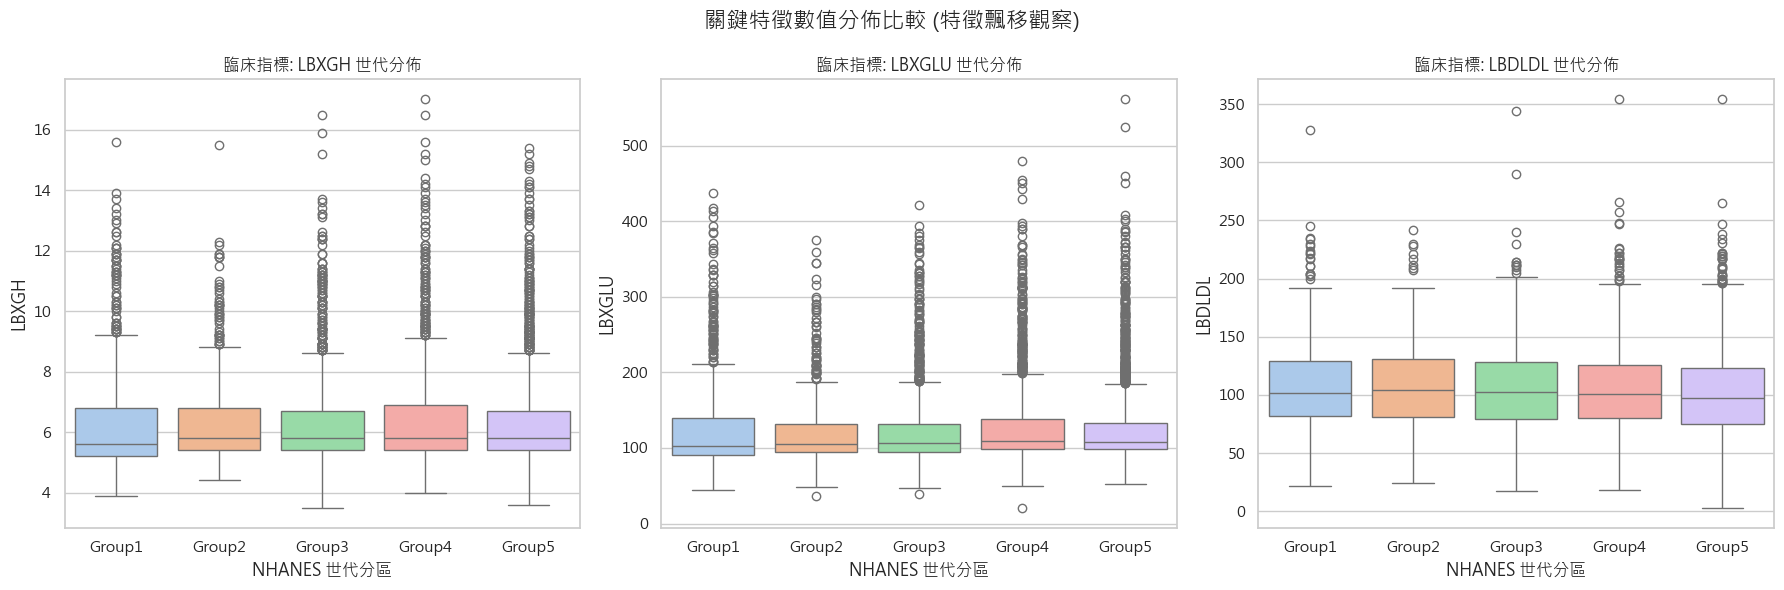

In [5]:
year_groups = ["Group1", "Group2", "Group3", "Group4", "Group5"]

# ==========================================
# 2. 產出 Non-IID 資料檢核報表與圖表

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang HK', 'SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

key_features = ["LBXGH", "LBXGLU", "LBDLDL"] 
summary_data = []
all_df = pd.DataFrame()

# 讀取資料並計算摘要統計
for group_name in year_groups:
    file_path = f'./data/raw/balance_data_{group_name}.csv'
    
    if not os.path.exists(file_path):
        print(f"找不到檔案: {file_path}")
        continue
        
    df = pd.read_csv(file_path)
    
    # 模仿 preprocessing.py 的標籤處理，清理出真實的分佈
    df = df[df['DIQ010'] != 9.0].reset_index(drop=True)
    df['DIQ010'] = df['DIQ010'].replace({3.0: 1.0, 2.0: 0.0})
    
    df['Partition'] = group_name
    all_df = pd.concat([all_df, df], ignore_index=True)
    
    # 計算樣本數與標籤分佈
    total_samples = len(df)
    counts = df['DIQ010'].value_counts()
    pos_count = counts.get(1.0, 0)
    neg_count = counts.get(0.0, 0)
    
    stats = {
        "時間分區": group_name,
        "總樣本數": total_samples,
        "糖尿病 (1)": pos_count,
        "非糖尿病 (0)": neg_count,
    }
    
    # 計算關鍵特徵的平均值與標準差
    for feat in key_features:
        if feat in df.columns:
            stats[f"{feat} 平均值"] = round(df[feat].mean(), 2)
            stats[f"{feat} 標準差"] = round(df[feat].std(), 2)
            
    summary_data.append(stats)

# 輸出表格
print("====== 各分區資料摘要統計表格 (Non-IID 檢核) ======")
summary_df = pd.DataFrame(summary_data)
display(summary_df)


# 圖表 B：關鍵特徵箱型圖
num_features = len(key_features)
fig, axes = plt.subplots(1, num_features, figsize=(6 * num_features, 6))

for i, feat in enumerate(key_features):
    if feat in all_df.columns:
        sns.boxplot(data=all_df, x="Partition", y=feat, ax=axes[i], palette="pastel")
        axes[i].set_title(f"臨床指標: {feat} 世代分佈", fontsize=12)
        axes[i].set_xlabel("NHANES 世代分區")
        axes[i].set_ylabel(feat)

plt.suptitle("關鍵特徵數值分佈比較 (特徵飄移觀察)", fontsize=16)
plt.tight_layout()
plt.show()